# 08 - Recherche de transactions similaires avec SHAP + Qdrant

Objectif : répondre à la partie optionnelle du sujet.

> Étant donné une transaction suspecte, retrouver dans l'historique les 5 transactions les plus similaires pour aider un analyste fraude à reconstituer un pattern.

Approche retenue :

- entraîner un XGBoost compact, identique à la baseline du projet ;
- encoder les transactions avec les **SHAP values** du modèle ;
- indexer les embeddings SHAP des transactions historiques dans **Qdrant** ;
- interroger Qdrant avec une fraude détectée en validation ;
- comparer les 5 transactions historiques les plus proches.


## 1. Pré-requis Qdrant

Lance Qdrant localement avant les cellules d'indexation :

```bash
docker run -p 6333:6333 -p 6334:6334   -v "$(pwd)/qdrant_storage:/qdrant/storage"   qdrant/qdrant
```

Installe le client Python si besoin :

```bash
pip install qdrant-client
```

Le notebook fonctionne en deux parties :

1. préparation du modèle et des embeddings SHAP ;
2. connexion à Qdrant, indexation et recherche.


In [1]:
from pathlib import Path
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

import shap
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, normalize

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
ASSETS_DIR = PROJECT_ROOT / "docs" / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR = PROJECT_ROOT / "docs"
DOCS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY_PATH = DATA_DIR / "train_identity.csv"

for path in [TRAIN_TRANSACTION_PATH, TRAIN_IDENTITY_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Fichier introuvable : {path.resolve()}")


def save_plot(filename):
    output_path = ASSETS_DIR / filename
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    print(f"Figure sauvegardee : {output_path}")


/home/fenitra/.pyenv/versions/fraude/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
VALID_SIZE = 0.20
DECISION_THRESHOLD = 0.25

# On limite l'index historique pour garder une démo locale raisonnable.
# Augmente cette valeur si ta machine supporte le calcul SHAP + l'indexation Qdrant.
MAX_HISTORY_ROWS_TO_INDEX = 50_000
SIMILARITY_TOP_K = 5

QDRANT_URL = "http://localhost:6333"
QDRANT_COLLECTION = "fraud_transactions_shap"

BASE_XGB_PARAMS = dict(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


## 2. Chargement et features temporelles

On reprend le pipeline compact du projet pour rester comparable aux résultats XGBoost déjà analysés. Les features temporelles utilisent uniquement l'historique passé par `customer_proxy`, pour éviter une fuite temporelle.


In [3]:
start = time.time()

train = (
    pl.scan_csv(TRAIN_TRANSACTION_PATH)
    .join(pl.scan_csv(TRAIN_IDENTITY_PATH), on="TransactionID", how="left")
    .sort("TransactionDT")
    .collect()
)

SECONDS_PER_HOUR = 3600
SECONDS_PER_DAY = 24 * SECONDS_PER_HOUR
SECONDS_PER_WEEK = 7 * SECONDS_PER_DAY

train = train.with_columns([
    (pl.col("TransactionDT") // SECONDS_PER_HOUR).cast(pl.Int64).alias("hour_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_DAY).cast(pl.Int64).alias("day_rel"),
    (pl.col("TransactionDT") // SECONDS_PER_WEEK).cast(pl.Int64).alias("week_rel"),
    ((pl.col("TransactionDT") // SECONDS_PER_HOUR) % 24).cast(pl.Int64).alias("hour_of_day_rel"),
])

print(f"Dataset charge : {train.shape}")
print(f"Temps : {time.time() - start:.1f} secondes")


Dataset charge : (590540, 438)
Temps : 99.0 secondes


In [4]:
id_cols = [col for col in ["card1", "card2", "card3", "card5", "addr1"] if col in train.columns]
merchant_cols = [col for col in ["ProductCD", "R_emaildomain"] if col in train.columns]

WINDOW_SPECS = {
    "1h": 60 * 60,
    "24h": 24 * 60 * 60,
    "7d": 7 * 24 * 60 * 60,
}

train = (
    train
    .with_row_count("txn_row_id")
    .with_columns([
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in id_cols], separator="_").alias("customer_proxy"),
        pl.concat_str([pl.col(c).cast(pl.Utf8).fill_null("missing") for c in merchant_cols], separator="_").alias("merchant_proxy"),
    ])
    .sort(["customer_proxy", "TransactionDT", "txn_row_id"])
    .with_columns([
        pl.cum_count("TransactionID").over("customer_proxy").alias("customer_tx_count_cum"),
        pl.col("TransactionAmt").cum_sum().over("customer_proxy").alias("customer_amt_cumsum"),
        pl.cum_count("TransactionID").over(["customer_proxy", "merchant_proxy"]).sub(1).alias("merchant_seen_count_prev"),
    ])
    .with_columns([
        pl.col("customer_tx_count_cum").sub(1).alias("customer_tx_count_prev"),
        (pl.col("customer_amt_cumsum") - pl.col("TransactionAmt")).alias("customer_amt_sum_prev"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("customer_amt_sum_prev") / pl.col("customer_tx_count_prev"))
        .otherwise(None)
        .alias("customer_amt_mean_prev"),
        (pl.col("merchant_seen_count_prev") == 0).cast(pl.Int8).alias("is_new_merchant_for_customer"),
    ])
    .with_columns([
        pl.when(pl.col("customer_tx_count_prev") > 0)
        .then(pl.col("TransactionAmt") / pl.col("customer_amt_mean_prev"))
        .otherwise(None)
        .alias("amt_to_customer_mean_prev"),
    ])
)

history_lookup = train.select([
    "customer_proxy",
    "TransactionDT",
    "customer_tx_count_cum",
    "customer_amt_cumsum",
]).sort("TransactionDT")

helper_cols_to_drop = ["customer_tx_count_cum", "customer_amt_cumsum"]
window_features = []

for label, seconds in WINDOW_SPECS.items():
    before_count_col = f"customer_tx_count_before_{label}"
    before_sum_col = f"customer_amt_sum_before_{label}"
    count_col = f"customer_tx_count_prev_{label}"
    sum_col = f"customer_amt_sum_prev_{label}"

    cutoff_points = (
        train
        .select([
            "txn_row_id",
            "customer_proxy",
            (pl.col("TransactionDT") - seconds).alias("window_start_dt"),
        ])
        .sort("window_start_dt")
    )

    window_start_history = (
        cutoff_points
        .join_asof(
            history_lookup,
            left_on="window_start_dt",
            right_on="TransactionDT",
            by="customer_proxy",
            strategy="backward",
        )
        .select([
            "txn_row_id",
            pl.col("customer_tx_count_cum").fill_null(0).alias(before_count_col),
            pl.col("customer_amt_cumsum").fill_null(0.0).alias(before_sum_col),
        ])
    )

    train = (
        train
        .join(window_start_history, on="txn_row_id", how="left")
        .with_columns([
            pl.max_horizontal([pl.col("customer_tx_count_prev") - pl.col(before_count_col), pl.lit(0)]).alias(count_col),
            pl.max_horizontal([pl.col("customer_amt_sum_prev") - pl.col(before_sum_col), pl.lit(0.0)]).alias(sum_col),
        ])
    )

    window_features.extend([count_col, sum_col])
    helper_cols_to_drop.extend([before_count_col, before_sum_col])

engineered_features = [
    "customer_tx_count_prev",
    "customer_amt_mean_prev",
    "amt_to_customer_mean_prev",
    "is_new_merchant_for_customer",
] + window_features

train = train.drop(helper_cols_to_drop).sort("txn_row_id")
print(f"Features temporelles : {engineered_features}")


Features temporelles : ['customer_tx_count_prev', 'customer_amt_mean_prev', 'amt_to_customer_mean_prev', 'is_new_merchant_for_customer', 'customer_tx_count_prev_1h', 'customer_amt_sum_prev_1h', 'customer_tx_count_prev_24h', 'customer_amt_sum_prev_24h', 'customer_tx_count_prev_7d', 'customer_amt_sum_prev_7d']


## 3. Modèle XGBoost compact

On entraîne un modèle compact : c'est le modèle le plus défendable dans le rapport actuel, car les essais avec `Vxxx` n'ont pas amélioré l'AUPRC. Les SHAP values de ce modèle serviront d'embeddings de similarité.


In [5]:
compact_numeric_candidates = [
    "TransactionAmt",
    "card1", "card2", "card3", "card5",
    "addr1", "addr2", "dist1", "dist2",
    "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9", "C10", "C11", "C12", "C13", "C14",
    "D1", "D2", "D3", "D4", "D5", "D10", "D15",
    "hour_rel", "day_rel", "week_rel", "hour_of_day_rel",
]

numeric_features = [col for col in compact_numeric_candidates if col in train.columns]

candidate_categorical_features = [
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "DeviceType", "id_12", "id_15", "id_16", "id_28", "id_29",
    "id_35", "id_36", "id_37", "id_38",
]
categorical_features = [col for col in candidate_categorical_features if col in train.columns]
feature_cols = list(dict.fromkeys(numeric_features + categorical_features + engineered_features))

payload_columns = [
    "TransactionID", "TransactionDT", "TransactionAmt", "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "P_emaildomain", "R_emaildomain", "DeviceType",
    "customer_proxy", "merchant_proxy", "day_rel", "hour_of_day_rel",
]
payload_columns = [col for col in payload_columns if col in train.columns]

model_columns = list(dict.fromkeys(feature_cols + ["isFraud"] + payload_columns))
split_idx = int(train.height * (1 - VALID_SIZE))
train_pd = train.slice(0, split_idx).select(model_columns).to_pandas()
valid_pd = train.slice(split_idx, train.height - split_idx).select(model_columns).to_pandas()

# On libere le Polars DataFrame complet après conversion des colonnes utiles.
del train
gc.collect()

X_train = train_pd[feature_cols]
y_train = train_pd["isFraud"].astype(int)
X_valid = valid_pd[feature_cols]
y_valid = valid_pd["isFraud"].astype(int)

print(f"Features totales : {len(feature_cols)}")
print(f"Train : {X_train.shape}, jours {train_pd['day_rel'].min()} -> {train_pd['day_rel'].max()}")
print(f"Valid : {X_valid.shape}, jours {valid_pd['day_rel'].min()} -> {valid_pd['day_rel'].max()}")
print(f"Taux fraude train : {y_train.mean():.4%}")
print(f"Taux fraude valid : {y_valid.mean():.4%}")


Features totales : 59
Train : (472432, 59), jours 1 -> 141
Valid : (118108, 59), jours 141 -> 182
Taux fraude train : 3.5135%
Taux fraude valid : 3.4409%


In [6]:
numeric_features_final = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features_final = [col for col in feature_cols if col not in numeric_features_final]

numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features_final),
        ("cat", categorical_pipeline, categorical_features_final),
    ],
    remainder="drop",
)

start = time.time()
X_train_prepared = preprocess.fit_transform(X_train)
X_valid_prepared = preprocess.transform(X_valid)
feature_names_prepared = numeric_features_final + categorical_features_final
print(f"Preprocessing : {time.time() - start:.1f} secondes")
print(f"X_train_prepared : {X_train_prepared.shape}")
print(f"X_valid_prepared : {X_valid_prepared.shape}")


Preprocessing : 7.8 secondes
X_train_prepared : (472432, 59)
X_valid_prepared : (118108, 59)


In [7]:
model = XGBClassifier(**BASE_XGB_PARAMS)
start = time.time()
model.fit(X_train_prepared, y_train.to_numpy())
train_time = time.time() - start

valid_scores = model.predict_proba(X_valid_prepared)[:, 1]
valid_pred = (valid_scores >= DECISION_THRESHOLD).astype(int)

metrics = {
    "AUPRC": average_precision_score(y_valid, valid_scores),
    f"precision@{DECISION_THRESHOLD}": precision_score(y_valid, valid_pred, zero_division=0),
    f"recall@{DECISION_THRESHOLD}": recall_score(y_valid, valid_pred, zero_division=0),
    f"F1@{DECISION_THRESHOLD}": f1_score(y_valid, valid_pred, zero_division=0),
    "alert_rate": float(valid_pred.mean()),
    "train_time_sec": train_time,
}

display(pd.Series(metrics).to_frame("xgboost_compact"))


,xgboost_compact
AUPRC,0.4753
precision@0.25,0.5843
recall@0.25,0.4129
F1@0.25,0.4839
alert_rate,0.0243
train_time_sec,8.3058


## 4. Embeddings SHAP

Chaque transaction est représentée par un vecteur de SHAP values. Deux transactions proches dans cet espace sont similaires du point de vue du modèle : les mêmes variables poussent le score de fraude dans les mêmes directions.

Pour éviter une fuite temporelle, l'index historique contient uniquement des transactions du train. La requête utilise une transaction de validation.


In [8]:
explainer = shap.TreeExplainer(model)

history_size = min(MAX_HISTORY_ROWS_TO_INDEX, X_train_prepared.shape[0])
history_start = X_train_prepared.shape[0] - history_size
history_idx = np.arange(history_start, X_train_prepared.shape[0])

X_history_prepared = X_train_prepared[history_idx]
history_meta = train_pd.iloc[history_idx].reset_index(drop=True).copy()
history_y = y_train.iloc[history_idx].reset_index(drop=True)

start = time.time()
history_shap = explainer.shap_values(X_history_prepared)
if isinstance(history_shap, list):
    history_shap = history_shap[1]
history_vectors = normalize(np.asarray(history_shap), norm="l2")
print(f"SHAP historique : {history_vectors.shape}, temps {time.time() - start:.1f}s")

start = time.time()
valid_shap = explainer.shap_values(X_valid_prepared)
if isinstance(valid_shap, list):
    valid_shap = valid_shap[1]
valid_vectors = normalize(np.asarray(valid_shap), norm="l2")
print(f"SHAP validation : {valid_vectors.shape}, temps {time.time() - start:.1f}s")


SHAP historique : (50000, 59), temps 2.0s
SHAP validation : (118108, 59), temps 4.9s


In [9]:
def top_shap_features(shap_row, feature_names, n=5):
    order = np.argsort(np.abs(shap_row))[::-1][:n]
    return [
        {
            "feature": feature_names[i],
            "shap_value": float(shap_row[i]),
        }
        for i in order
    ]

# Transaction suspecte de validation : fraude vraie et score supérieur au seuil.
candidate_idx = np.where((y_valid.to_numpy() == 1) & (valid_scores >= DECISION_THRESHOLD))[0]
if len(candidate_idx) == 0:
    # Fallback : fraude vraie avec le plus haut score.
    fraud_idx = np.where(y_valid.to_numpy() == 1)[0]
    query_idx = int(fraud_idx[np.argmax(valid_scores[fraud_idx])])
else:
    query_idx = int(candidate_idx[np.argmax(valid_scores[candidate_idx])])

query_meta = valid_pd.iloc[query_idx].copy()
query_vector = valid_vectors[query_idx]
query_shap = valid_shap[query_idx]
query_top_shap = top_shap_features(query_shap, feature_names_prepared, n=8)

print("Transaction requête")
print("TransactionID :", int(query_meta["TransactionID"]))
print("isFraud       :", int(query_meta["isFraud"]))
print("score fraude  :", float(valid_scores[query_idx]))
print("jour relatif  :", int(query_meta["day_rel"]))
print("Top SHAP :")
display(pd.DataFrame(query_top_shap))


Transaction requête
TransactionID : 3504601
isFraud       : 1
score fraude  : 0.9851568937301636
jour relatif  : 156
Top SHAP :


,feature,shap_value
0,C1,1.4212
1,C14,1.3398
2,C8,0.7288
3,C13,0.6654
4,C4,0.5569
5,C2,0.4255
6,C11,0.4135
7,TransactionAmt,0.2898


## 5. Indexation dans Qdrant

Cette cellule crée ou remplace une collection Qdrant. Chaque point contient :

- le vecteur SHAP normalisé ;
- le statut fraude / légitime ;
- les principaux champs métier utiles à l'analyste ;
- les top features SHAP de la transaction historique.


In [10]:
try:
    from qdrant_client import QdrantClient
    from qdrant_client.models import Distance, PointStruct, VectorParams
except ImportError as exc:
    raise ImportError(
        "qdrant-client n'est pas installé. Installe-le avec : pip install qdrant-client"
    ) from exc

client = QdrantClient(url=QDRANT_URL)
print(client.get_collections())


collections=[CollectionDescription(name='fraud_transactions_shap'), CollectionDescription(name='rag_books_qween_v1'), CollectionDescription(name='rag_books_qween_v1_test'), CollectionDescription(name='rag_books_qween_v2_test'), CollectionDescription(name='rag_books_v1')]


In [11]:
vector_size = history_vectors.shape[1]

if client.collection_exists(QDRANT_COLLECTION):
    client.delete_collection(QDRANT_COLLECTION)

client.create_collection(
    collection_name=QDRANT_COLLECTION,
    vectors_config=VectorParams(size=vector_size, distance=Distance.COSINE),
)

print(f"Collection creee : {QDRANT_COLLECTION}, vector_size={vector_size}")


Collection creee : fraud_transactions_shap, vector_size=59


In [12]:
def make_payload(row, y_value, shap_row):
    payload = {
        "TransactionID": int(row["TransactionID"]),
        "isFraud": int(y_value),
        "TransactionAmt": float(row["TransactionAmt"]) if pd.notna(row.get("TransactionAmt")) else None,
        "day_rel": int(row["day_rel"]) if pd.notna(row.get("day_rel")) else None,
        "top_shap_features": json.dumps(top_shap_features(shap_row, feature_names_prepared, n=5)),
    }

    for col in [
        "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
        "addr1", "addr2", "P_emaildomain", "R_emaildomain", "DeviceType",
        "customer_proxy", "merchant_proxy", "hour_of_day_rel",
    ]:
        if col in row.index:
            value = row[col]
            payload[col] = None if pd.isna(value) else str(value)
    return payload

batch_size = 2_000
start = time.time()

for start_idx in range(0, history_vectors.shape[0], batch_size):
    end_idx = min(start_idx + batch_size, history_vectors.shape[0])
    points = []
    for local_idx in range(start_idx, end_idx):
        row = history_meta.iloc[local_idx]
        point_id = int(row["TransactionID"])
        payload = make_payload(row, history_y.iloc[local_idx], history_shap[local_idx])
        points.append(PointStruct(id=point_id, vector=history_vectors[local_idx].tolist(), payload=payload))

    client.upsert(collection_name=QDRANT_COLLECTION, points=points)
    print(f"Indexe {end_idx}/{history_vectors.shape[0]}")

print(f"Indexation terminee en {time.time() - start:.1f}s")


Indexe 2000/50000
Indexe 4000/50000
Indexe 6000/50000
Indexe 8000/50000
Indexe 10000/50000
Indexe 12000/50000
Indexe 14000/50000
Indexe 16000/50000
Indexe 18000/50000
Indexe 20000/50000
Indexe 22000/50000
Indexe 24000/50000
Indexe 26000/50000
Indexe 28000/50000
Indexe 30000/50000
Indexe 32000/50000
Indexe 34000/50000
Indexe 36000/50000
Indexe 38000/50000
Indexe 40000/50000
Indexe 42000/50000
Indexe 44000/50000
Indexe 46000/50000
Indexe 48000/50000
Indexe 50000/50000
Indexation terminee en 34.9s


## 6. Recherche des 5 transactions similaires

On interroge Qdrant avec l'embedding SHAP de la transaction suspecte. Les voisins retournés sont des transactions passées du train, donc déjà connues dans l'historique.


In [13]:
# Compatibilite qdrant-client :
# - anciennes versions : client.search(..., query_vector=...)
# - versions recentes : client.query_points(..., query=...)
if hasattr(client, "search"):
    search_result = client.search(
        collection_name=QDRANT_COLLECTION,
        query_vector=query_vector.tolist(),
        limit=SIMILARITY_TOP_K,
        with_payload=True,
    )
else:
    query_response = client.query_points(
        collection_name=QDRANT_COLLECTION,
        query=query_vector.tolist(),
        limit=SIMILARITY_TOP_K,
        with_payload=True,
    )
    search_result = query_response.points

similar_rows = []
for rank, hit in enumerate(search_result, start=1):
    payload = dict(hit.payload)
    payload["rank"] = rank
    payload["similarity_score"] = float(hit.score)
    similar_rows.append(payload)

similar_df = pd.DataFrame(similar_rows)
cols_first = [
    "rank", "similarity_score", "TransactionID", "isFraud", "TransactionAmt",
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "DeviceType", "day_rel", "hour_of_day_rel",
]
cols_first = [col for col in cols_first if col in similar_df.columns]
similar_df = similar_df[cols_first + [col for col in similar_df.columns if col not in cols_first]]
display(similar_df)


,rank,similarity_score,TransactionID,isFraud,TransactionAmt,ProductCD,card4,card6,P_emaildomain,R_emaildomain,DeviceType,day_rel,hour_of_day_rel,top_shap_features,card1,card2,card3,card5,addr1,addr2,customer_proxy,merchant_proxy
0,1,0.9894,3414890,1,200.0000,R,visa,credit,gmail.com,gmail.com,desktop,125,1,"[{""feature"": ""C14"", ""shap_value"": 1.4822168350...",11106,100.0,150.0,226.0,343.0,87.0,11106_100.0_150.0_226.0_343.0,R_gmail.com
1,2,0.9883,3431994,1,150.0000,R,visa,credit,gmail.com,gmail.com,mobile,130,22,"[{""feature"": ""C14"", ""shap_value"": 1.4507075548...",6019,583.0,150.0,226.0,264.0,87.0,6019_583.0_150.0_226.0_264.0,R_gmail.com
2,3,0.9881,3414926,1,200.0000,R,visa,credit,gmail.com,gmail.com,desktop,125,1,"[{""feature"": ""C14"", ""shap_value"": 1.4441241025...",11106,100.0,150.0,226.0,343.0,87.0,11106_100.0_150.0_226.0_343.0,R_gmail.com
3,4,0.9783,3444076,1,275.0000,R,mastercard,credit,yahoo.com,yahoo.com,mobile,135,12,"[{""feature"": ""C14"", ""shap_value"": 1.4159250259...",10486,514.0,150.0,219.0,191.0,87.0,10486_514.0_150.0_219.0_191.0,R_yahoo.com
4,5,0.9648,3416662,1,200.0000,R,american express,credit,gmail.com,gmail.com,mobile,125,17,"[{""feature"": ""C14"", ""shap_value"": 1.4922020435...",9401,555.0,150.0,143.0,126.0,87.0,9401_555.0_150.0_143.0_126.0,R_gmail.com


In [14]:
query_display = {
    "TransactionID": int(query_meta["TransactionID"]),
    "isFraud": int(query_meta["isFraud"]),
    "score_fraude": float(valid_scores[query_idx]),
    "TransactionAmt": float(query_meta["TransactionAmt"]),
    "ProductCD": str(query_meta.get("ProductCD")),
    "card4": str(query_meta.get("card4")),
    "card6": str(query_meta.get("card6")),
    "P_emaildomain": str(query_meta.get("P_emaildomain")),
    "R_emaildomain": str(query_meta.get("R_emaildomain")),
    "DeviceType": str(query_meta.get("DeviceType")),
    "day_rel": int(query_meta["day_rel"]),
}

print("Transaction suspecte requête :")
display(pd.Series(query_display).to_frame("query_transaction"))

print("Top SHAP de la transaction requête :")
display(pd.DataFrame(query_top_shap))

print("Top SHAP des voisins similaires :")
for _, row in similar_df.iterrows():
    print(f"\nRank {row['rank']} - TransactionID {row['TransactionID']} - isFraud={row['isFraud']} - similarite={row['similarity_score']:.4f}")
    try:
        display(pd.DataFrame(json.loads(row["top_shap_features"])))
    except Exception:
        print(row.get("top_shap_features"))


Transaction suspecte requête :


,query_transaction
TransactionID,3504601
isFraud,1
score_fraude,0.9852
TransactionAmt,200.0000
ProductCD,R
card4,visa
card6,credit
P_emaildomain,gmail.com
R_emaildomain,gmail.com
DeviceType,mobile


Top SHAP de la transaction requête :


,feature,shap_value
0,C1,1.4212
1,C14,1.3398
2,C8,0.7288
3,C13,0.6654
4,C4,0.5569
5,C2,0.4255
6,C11,0.4135
7,TransactionAmt,0.2898


Top SHAP des voisins similaires :

Rank 1 - TransactionID 3414890 - isFraud=1 - similarite=0.9894


...

,feature,shap_value
0,C14,1.4441
1,C1,1.3313
2,C8,0.8120
3,C13,0.6636
4,C4,0.5999



Rank 4 - TransactionID 3444076 - isFraud=1 - similarite=0.9783


,feature,shap_value
0,C14,1.4159
1,C1,1.2436
2,C13,0.7003
3,C8,0.5675
4,C4,0.5248



Rank 5 - TransactionID 3416662 - isFraud=1 - similarite=0.9648


,feature,shap_value
0,C14,1.4922
1,C1,1.2859
2,C4,0.6187
3,C13,0.6038
4,C11,0.3859


## 7. Analyse analyste

L'objectif n'est pas seulement de récupérer des voisins mathématiques : il faut vérifier si un analyste peut reconstituer un pattern.

On regarde donc :

- combien de voisins sont frauduleux ;
- s'ils partagent des variables métier : produit, carte, domaine email, device, montant ;
- si les top SHAP features sont similaires à celles de la transaction requête.


In [15]:
neighbor_fraud_rate = similar_df["isFraud"].astype(int).mean() if len(similar_df) else np.nan
same_product_rate = (similar_df["ProductCD"].astype(str) == str(query_meta.get("ProductCD"))).mean() if "ProductCD" in similar_df else np.nan
same_card6_rate = (similar_df["card6"].astype(str) == str(query_meta.get("card6"))).mean() if "card6" in similar_df else np.nan
same_device_rate = (similar_df["DeviceType"].astype(str) == str(query_meta.get("DeviceType"))).mean() if "DeviceType" in similar_df else np.nan

analysis_summary = {
    "query_transaction_id": int(query_meta["TransactionID"]),
    "query_score": float(valid_scores[query_idx]),
    "neighbors_count": int(len(similar_df)),
    "neighbor_fraud_rate": float(neighbor_fraud_rate),
    "same_product_rate": None if pd.isna(same_product_rate) else float(same_product_rate),
    "same_card6_rate": None if pd.isna(same_card6_rate) else float(same_card6_rate),
    "same_device_rate": None if pd.isna(same_device_rate) else float(same_device_rate),
    "indexed_history_rows": int(history_vectors.shape[0]),
    "embedding_type": "SHAP values from compact XGBoost",
    "qdrant_collection": QDRANT_COLLECTION,
}

display(pd.Series(analysis_summary).to_frame("similarity_search_summary"))

summary_path = DOCS_DIR / "similarity_search_summary.json"
summary_path.write_text(json.dumps(analysis_summary, indent=2), encoding="utf-8")

results_path = DOCS_DIR / "similarity_search_results.csv"
similar_df.to_csv(results_path, index=False)

print(f"Resume sauvegarde : {summary_path}")
print(f"Resultats sauvegardes : {results_path}")


,similarity_search_summary
query_transaction_id,3504601
query_score,0.9852
neighbors_count,5
neighbor_fraud_rate,1.0000
same_product_rate,1.0000
same_card6_rate,1.0000
same_device_rate,0.6000
indexed_history_rows,50000
embedding_type,SHAP values from compact XGBoost
qdrant_collection,fraud_transactions_shap


Resume sauvegarde : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/similarity_search_summary.json
Resultats sauvegardes : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/similarity_search_results.csv


Figure sauvegardee : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/assets/08_similarity_search_top5.png


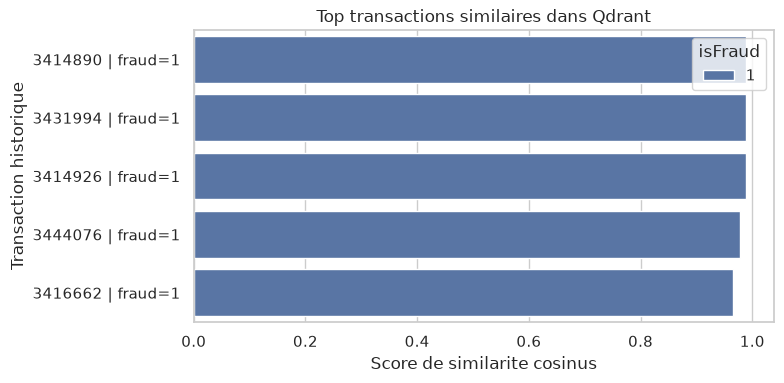

In [16]:
plot_df = similar_df.copy()
plot_df["label"] = plot_df["TransactionID"].astype(str) + " | fraud=" + plot_df["isFraud"].astype(str)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x="similarity_score", y="label", hue="isFraud", dodge=False, ax=ax)
ax.set_title("Top transactions similaires dans Qdrant")
ax.set_xlabel("Score de similarite cosinus")
ax.set_ylabel("Transaction historique")
plt.tight_layout()
save_plot("08_similarity_search_top5.png")
plt.show()


## 8. Conclusion à intégrer au rapport

Template de conclusion :

> Nous avons implémenté un moteur de recherche de transactions similaires basé sur les SHAP values du modèle XGBoost compact. Chaque transaction historique est représentée par un vecteur décrivant les contributions des features à son score de fraude, puis indexée dans Qdrant avec une distance cosinus. Pour une transaction frauduleuse détectée en validation, le système retourne les 5 transactions passées les plus proches. L'analyste peut comparer le statut fraude, le montant, le produit, la carte, les domaines email, le device et les top SHAP features pour reconstituer un pattern.

Limite : l'index local est limité par défaut à `MAX_HISTORY_ROWS_TO_INDEX` transactions historiques pour garder une exécution raisonnable. En production, il faudrait indexer toutes les transactions passées et gérer les mises à jour incrémentales.


In [17]:
report = f'''# Rapport - Recherche de transactions similaires avec SHAP + Qdrant

## Objectif

Cette partie répond à l'option du sujet : retrouver, pour une transaction suspecte, les 5 transactions historiques les plus similaires.

## Méthode

- Modèle utilisé : XGBoost compact.
- Embedding : SHAP values de chaque transaction.
- Index vectoriel : Qdrant local.
- Distance : cosinus.
- Historique indexé : {history_vectors.shape[0]:,} transactions train.
- Requête : transaction de validation `TransactionID={int(query_meta['TransactionID'])}`, score fraude `{float(valid_scores[query_idx]):.4f}`.

## Résultat

Les 5 voisins les plus similaires sont sauvegardés dans `docs/similarity_search_results.csv`.

![Top transactions similaires](assets/08_similarity_search_top5.png)

## Lecture analyste

Le taux de fraude parmi les voisins est `{neighbor_fraud_rate:.2%}`. L'analyste peut comparer les montants, produits, cartes, emails, devices et top SHAP features pour vérifier si la transaction suspecte appartient à un pattern déjà observé.

## Limites

L'index est limité à `{history_vectors.shape[0]:,}` transactions pour garder une démo locale raisonnable. Une version production devrait indexer tout l'historique passé, mettre à jour Qdrant en continu et tracer les requêtes analystes.
'''

report_path = DOCS_DIR / "rapport_similarity_search_qdrant.md"
report_path.write_text(report, encoding="utf-8")
print(f"Rapport sauvegarde : {report_path}")


Rapport sauvegarde : /mnt/c/Users/tanjo/projetcs/fraud-scope/docs/rapport_similarity_search_qdrant.md
